# 와인 품질 예측하기


![](https://labelyourdata.com/img/article-illustrations/ml_essential_tool.jpg)

## 1.환경준비

### (1) 라이브러리 로딩

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

from keras.models import Sequential
from keras.layers import Dense, Input
from keras.backend import clear_session
from keras.optimizers import Adam

* 함수 만들기

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터로딩

In [3]:
path = "https://raw.githubusercontent.com/DA4BAM/dataset/master/winequality-white.csv"
data = pd.read_csv(path)
data['quality'] = np.where(data['quality'] == 3, 4, np.where(data['quality'] == 9, 8, data['quality']))
data['quality'] = data['quality'] - 4
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,2
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,2
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,2
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,2
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,2


* 범주가 5개 입니다.
    * 0 - 최하  ~  4 - 최상

In [4]:
data['quality'].value_counts()

,count
quality,
2,2198
1,1457
3,880
0,183
4,180


## 2.데이터 준비

### (1) 데이터 준비
* y에 대한 전처리 : 위에서 이미 0 ~ 4로 범주를 맞췄습니다.
* x, y 나누기

In [5]:
target = 'quality'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

### (2) 데이터 분할

In [6]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size= .3, random_state = 20)

### (3) 스케일링

In [7]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## 3.모델링

최소 3개 이상의 모델을 생성하고 성능을 비교하시오.

In [9]:
nfeatures = x_train.shape[1]
nfeatures

11

### (1) 모델1

In [11]:
clear_session()

model1 = Sequential( [Input(shape=(nfeatures,)),
                      Dense(201, activation='relu'),
                      Dense(101, activation='relu'),
                      Dense(51, activation='relu'),
                      Dense(11, activation='relu'),
                      Dense(5, activation='softmax')])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 201)                 │           2,412 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 101)                 │          20,402 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 51)                  │           5,202 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 11)                  │             572 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │              60 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,648 (111.91 KB)

 Trainable params: 28,648 (111.91 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model1.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy')

result1 = model1.fit(x_train, y_train, epochs=100, validation_split=0.2).history

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3437 - val_loss: 1.1178
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1966 - val_loss: 1.0648
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1666 - val_loss: 1.0268
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1249 - val_loss: 1.0238
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1021 - val_loss: 1.0052
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0856 - val_loss: 1.0363
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0783 - val_loss: 0.9962
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0673 - val_loss: 0.9866
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0667 - val_loss: 0.9794
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0593 - val_loss: 0.9942
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0566 - val_loss: 1.0218
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0

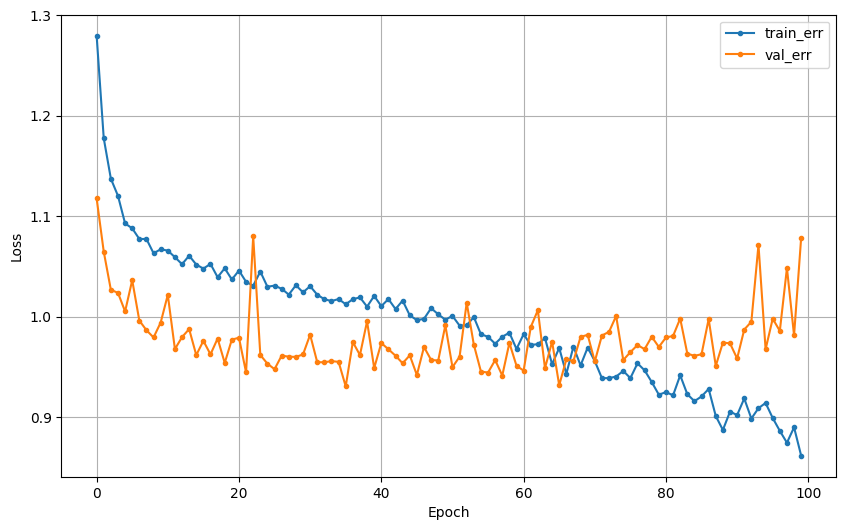

In [14]:
dl_history_plot(result1)

In [15]:
pred1 = model1.predict(x_val)

pred1 = np.argmax(pred1, axis=1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [16]:
print(confusion_matrix(y_val, pred1))
print(classification_report(y_val, pred1))

[[ 21  33   7   0   0]
 [ 24 300 101  13   0]
 [ 14 207 338  95   6]
 [  2  17 125  93  13]
 [  0   1  20  31   9]]
              precision    recall  f1-score   support

           0       0.34      0.34      0.34        61
           1       0.54      0.68      0.60       438
           2       0.57      0.51      0.54       660
           3       0.40      0.37      0.39       250
           4       0.32      0.15      0.20        61

    accuracy                           0.52      1470
   macro avg       0.44      0.41      0.42      1470
weighted avg       0.51      0.52      0.51      1470



### (2) 모델2

In [74]:
clear_session()

model2 = Sequential( [Input(shape=(nfeatures,)),
                      Dense(101, activation='relu'),
                      Dense(51, activation='relu'),
                      Dense(11, activation='relu'),
                      Dense(5, activation='softmax')])

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 101)                 │           1,212 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 51)                  │           5,202 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 11)                  │             572 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │              60 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,046 (27.52 KB)

 Trainable params: 7,046 (27.52 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
model2.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy')

result2= model2.fit(x_train, y_train, epochs=100, validation_split=0.2).history

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3057 - val_loss: 1.0681
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1542 - val_loss: 1.0034
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0988 - val_loss: 1.0744
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.1395 - val_loss: 0.9899
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0946 - val_loss: 1.0279
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0893 - val_loss: 0.9915
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0936 - val_loss: 1.0584
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0779 - val_loss: 1.0463
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0764 - val_loss: 0.9572
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0709 - val_loss: 0.9746
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0594 - val_loss: 0.9741
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0

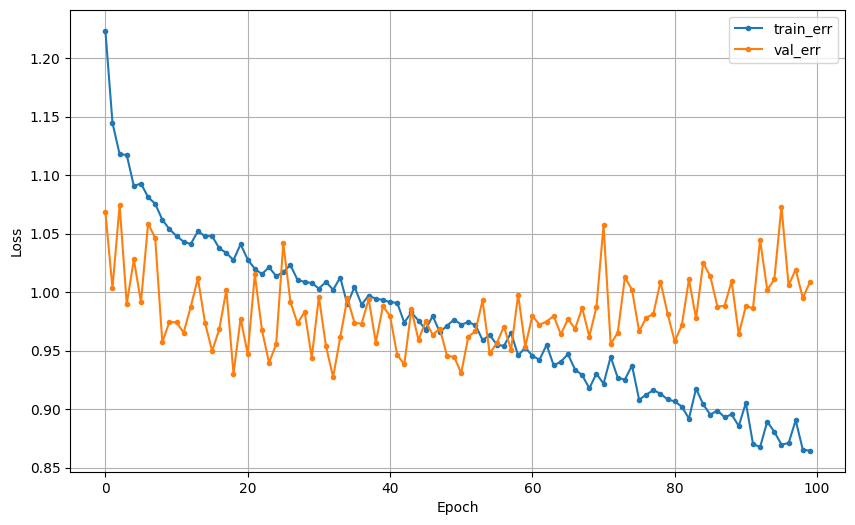

In [76]:
dl_history_plot(result2)

In [77]:
pred2 = model2.predict(x_val)

pred2 = np.argmax(pred2, axis=1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [78]:
print(confusion_matrix(y_val, pred2))
print(classification_report(y_val, pred2))

[[ 12  33  15   1   0]
 [ 13 240 169  14   2]
 [  4 140 392 122   2]
 [  0   8 119 119   4]
 [  0   0  17  42   2]]
              precision    recall  f1-score   support

           0       0.41      0.20      0.27        61
           1       0.57      0.55      0.56       438
           2       0.55      0.59      0.57       660
           3       0.40      0.48      0.43       250
           4       0.20      0.03      0.06        61

    accuracy                           0.52      1470
   macro avg       0.43      0.37      0.38      1470
weighted avg       0.51      0.52      0.51      1470



### (3) 모델3

In [84]:
clear_session()

model3 = Sequential( [Input(shape=(nfeatures,)),
                      Dense(10, activation='relu'),
                      Dense(7, activation='relu'),
                      Dense(5, activation='softmax')])

model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │              77 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │              40 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 237 (948.00 B)

 Trainable params: 237 (948.00 B)

 Non-trainable params: 0 (0.00 B)

In [85]:
model3.compile(optimizer=Adam(learning_rate=0.01), loss='sparse_categorical_crossentropy')

result3 = model3.fit(x_train, y_train, epochs=100, validation_split=0.2).history

Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.3742 - val_loss: 1.1531
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2094 - val_loss: 1.0604
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1760 - val_loss: 1.0495
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1318 - val_loss: 1.0206
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1193 - val_loss: 1.0060
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1133 - val_loss: 1.0231
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0713 - val_loss: 1.0148
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0945 - val_loss: 1.0156
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0899 - val_loss: 0.9953
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0522 - val_loss: 1.0108
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0857 - val_loss: 1.0026
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0

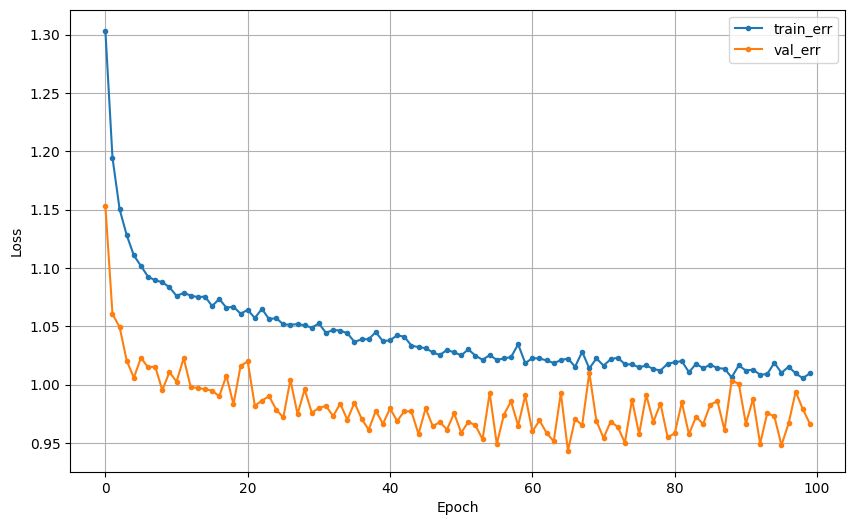

In [86]:
dl_history_plot(result3)

In [90]:
pred3 = model3.predict(x_val)

pred3 = np.argmax(pred3, axis=1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [91]:
print(confusion_matrix(y_val, pred3))
print(classification_report(y_val, pred3))

[[  7  41  13   0   0]
 [  1 251 180   5   1]
 [  1 131 479  48   1]
 [  0   8 185  57   0]
 [  0   1  40  20   0]]
              precision    recall  f1-score   support

           0       0.78      0.11      0.20        61
           1       0.58      0.57      0.58       438
           2       0.53      0.73      0.62       660
           3       0.44      0.23      0.30       250
           4       0.00      0.00      0.00        61

    accuracy                           0.54      1470
   macro avg       0.47      0.33      0.34      1470
weighted avg       0.52      0.54      0.51      1470



In [98]:
model4 = RandomForestClassifier(max_depth=15)

model4.fit(x_train, y_train)

y_pred = model4.predict(x_val)

print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

[[  8  24  27   2   0]
 [  3 289 141   4   1]
 [  0  85 548  27   0]
 [  0   3 116 128   3]
 [  0   0  25  16  20]]
              precision    recall  f1-score   support

           0       0.73      0.13      0.22        61
           1       0.72      0.66      0.69       438
           2       0.64      0.83      0.72       660
           3       0.72      0.51      0.60       250
           4       0.83      0.33      0.47        61

    accuracy                           0.68      1470
   macro avg       0.73      0.49      0.54      1470
weighted avg       0.69      0.68      0.66      1470

